### CFG Parsing Setup

This notebook builds a CKY chart parser for Russian using a hand-crafted CFG.

Design choices:
- **Principled phrase rules** covering Russian word-order variation (SVO/VSO), copula drop, negation, and predicative constructions — no noisy bigram induction.
- **Two evaluation modes**: (1) UPOS tag sequences — structural coverage, OOV impossible; (2) word-level — lexical + structural coverage, with optional pymorphy3 lemmatization.
- **Train/eval split**: grammar lexicon built from a training slice of `ru_train.conllu`; evaluation runs on a non-overlapping held-out slice.

In [73]:
from collections import defaultdict  # Efficient mapping for grammar rules
from pathlib import Path              # Cross-platform file paths

import matplotlib.pyplot as plt      # Plotting
import pandas as pd                  # Tabular data (used in coverage stats)
import seaborn as sns                # Extended plot styles

# pymorphy3 provides full Russian morphological analysis including lemmatization.
# It is optional: if absent, word-level evaluation falls back to surface forms.
try:
    import pymorphy3
    LEMMATIZE = True                  # Flag: lemmatizer available
except ImportError:
    LEMMATIZE = False                 # Flag: fall back to surface forms

Set Grammar Structure

In [74]:
# Grammar: nonterminal -> list of productions.
# Contains phrase structure rules only; lexical rules are added later from UD data.
grammar = defaultdict(list)

# --- S rules ---
# Russian is a free-word-order language; all major orders must be covered.
grammar["S"].append(["NP", "VP"])       # SVO: most frequent written order
grammar["S"].append(["VP", "NP"])       # VSO / verb-initial
grammar["S"].append(["VP"])             # Null-subject: dropped pronoun ("Читает.")
grammar["S"].append(["NP", "NP"])       # Copula drop: "Он студент" (He [is] student)
grammar["S"].append(["ADV", "ADJ"])     # Predicative: "Здесь холодно" (here [it is] cold)
grammar["S"].append(["ADV", "NP"])      # Locative predicative: "Здесь университет"
grammar["S"].append(["S", "S_CONJ"])    # Coordination (binarized; see S_CONJ below)

# --- NP rules ---
grammar["NP"].append(["NOUN"])          # Bare noun (case marks the role in Russian)
grammar["NP"].append(["PROPN"])         # Proper name
grammar["NP"].append(["PRON"])          # Pronoun
grammar["NP"].append(["NUM"])           # Bare numeral
grammar["NP"].append(["DET", "NOUN"])   # Determiner + noun
grammar["NP"].append(["ADJ", "NOUN"])   # Adjective + noun (pre-nominal; very common)
grammar["NP"].append(["NUM", "NOUN"])   # Numeral + noun
grammar["NP"].append(["NOUN", "NOUN"])  # Compound or genitive chain
grammar["NP"].append(["NP", "PP"])      # NP with prepositional modifier
grammar["NP"].append(["NP", "NP"])      # Apposition

# --- VP rules ---
grammar["VP"].append(["VERB"])          # Bare verb (intransitive / null-object)
grammar["VP"].append(["AUX", "VERB"])   # Auxiliary + main verb
grammar["VP"].append(["VERB", "NP"])    # Transitive verb + direct object
grammar["VP"].append(["VERB", "PP"])    # Verb + prepositional complement
grammar["VP"].append(["VP", "PP"])      # VP extended by prepositional phrase
grammar["VP"].append(["VERB", "ADV"])   # Verb + post-modifying adverb
grammar["VP"].append(["ADV", "VERB"])   # Pre-modifying adverb + verb
grammar["VP"].append(["PART", "VP"])    # Negation: не + VP  ("не читал книгу")
grammar["VP"].append(["PART", "VERB"])  # Negation: не + bare verb ("не читал")

# --- PP rules ---
grammar["PP"].append(["ADP", "NP"])     # Preposition + full NP
grammar["PP"].append(["ADP", "NOUN"])   # Preposition + bare noun
grammar["PP"].append(["ADP", "PROPN"])  # Preposition + proper name
grammar["PP"].append(["ADP", "PRON"])   # Preposition + pronoun

# --- Coordination (binarized for CKY; ternary S -> S CCONJ S is not allowed) ---
grammar["S_CONJ"].append(["CCONJ", "S"])  # Right branch: conjunction + clause
# S -> S S_CONJ completes the coordination and is already in the S rules above.

### CKY Parser

In [75]:
# Function to convert grammar into unary rule map for closure.
# Expand symbols in a chart cell using unary closure.
def apply_unary_closure(cell, unary_rules):
    # Start with current symbols in the cell.
    agenda = list(cell)
    # Keep expanding until no new unary parents appear.
    while agenda:
        # Pop one symbol to expand.
        symbol = agenda.pop()
        # Find all unary parents of the symbol.
        for parent in unary_rules.get(symbol, []):
            # Add unseen parent and continue closure search.
            if parent not in cell:
                cell.add(parent)
                agenda.append(parent)

    return cell

Word-Level Parser

In [ ]:
# Parse a tokenized (word-level) sentence with CKY.
def cky_parse(sentence, grammar, debug = False):
    n = len(sentence)
    if n == 0:                               # Guard: nothing to parse
        return []

    # Build n x n CKY chart; each cell holds a set of nonterminals.
    table = [[set() for _ in range(n)] for _ in range(n)]

    lexical_rules = defaultdict(list)        # word  -> [UPOS, ...]
    unary_rules   = defaultdict(list)        # child -> [parent, ...]
    binary_rules  = defaultdict(list)        # (B, C) -> [A, ...]
    nonterminals  = set(grammar.keys())      # All LHS symbols

    # Partition grammar rules by type (lexical / unary / binary).
    for lhs, productions in grammar.items():
        for production in productions:
            if len(production) == 1:
                rhs = production[0]
                if rhs in nonterminals:      # Unary nonterminal rule
                    unary_rules[rhs].append(lhs)
                else:                        # Lexical terminal rule
                    lexical_rules[rhs].append(lhs)
            elif len(production) == 2:       # Binary rule
                binary_rules[tuple(production)].append(lhs)

    # Fill chart diagonal with lexical matches.
    for i, word in enumerate(sentence):
        for lhs in lexical_rules.get(word, []):
            table[i][i].add(lhs)
        apply_unary_closure(table[i][i], unary_rules)
        if debug and not table[i][i]:        # Flag OOV words
            print(f"[OOV] '{word}' has no lexical coverage")

    # Fill spans from short to long (bottom-up).
    for span in range(2, n + 1):
        for i in range(n - span + 1):
            j = i + span - 1
            for k in range(i, j):            # Try all split points
                for B in table[i][k]:
                    for C in table[k + 1][j]:
                        for A in binary_rules.get((B, C), []):
                            table[i][j].add(A)
            apply_unary_closure(table[i][j], unary_rules)

    if debug:
        print(f"[DEBUG] Full span categories: {table[0][n - 1]}")

    return table

UPOS Tag-Sequence Parser

In [77]:
# Parse a UPOS tag sequence directly — no lexical lookup, so OOV is impossible.
# Each tag is seeded into its own chart cell; unary closure propagates to phrases.
# Use this as the primary evaluation mode to measure structural grammar coverage.
def cky_parse_upos(tag_sequence, grammar, debug=False):
    n = len(tag_sequence)
    if n == 0:                               # Guard: nothing to parse
        return []

    # Build n x n CKY chart.
    table = [[set() for _ in range(n)] for _ in range(n)]

    unary_rules  = defaultdict(list)         # child nonterminal -> [parent, ...]
    binary_rules = defaultdict(list)         # (B, C) -> [A, ...]
    nonterminals = set(grammar.keys())       # All LHS symbols

    # Partition only unary/binary rules (lexical rules not needed here).
    for lhs, productions in grammar.items():
        for production in productions:
            if len(production) == 1:
                rhs = production[0]
                if rhs in nonterminals:      # Nonterminal unary rule only
                    unary_rules[rhs].append(lhs)
            elif len(production) == 2:
                binary_rules[tuple(production)].append(lhs)

    # Seed each cell with its UPOS tag; closure propagates to phrase categories.
    for i, tag in enumerate(tag_sequence):
        table[i][i].add(tag)                 # Tag is its own initial category
        apply_unary_closure(table[i][i], unary_rules)
        if debug and len(table[i][i]) == 1:  # Only the raw tag — no phrase rules matched
            print(f"[WARN] '{tag}' has no phrase coverage")

    # Fill spans from short to long (identical algorithm to word-level CKY).
    for span in range(2, n + 1):
        for i in range(n - span + 1):
            j = i + span - 1
            for k in range(i, j):            # Try all split points
                for B in table[i][k]:
                    for C in table[k + 1][j]:
                        for A in binary_rules.get((B, C), []):
                            table[i][j].add(A)
            apply_unary_closure(table[i][j], unary_rules)

    if debug:
        print(f"[DEBUG] Full span categories: {table[0][n - 1]}")

    return table

### Sentence Validation

In [78]:
# Function to check if sentence is grammatical based on CKY table
# Return True when top-right CKY cell contains start symbol S
def is_grammatical(table):
    # Guard against empty parse tables
    if not table:
        return False
    # Get chart dimension
    n = len(table)
    # Sentence is grammatical if S covers full span
    return "S" in table[0][n - 1]

### Toy Sentence Demo

A small inline `demo_grammar` is used here so the toy demo stays independent of the UD-expanded evaluation grammar.  The toy lexical entries (я, вижу, собаку) are not added to the main grammar.

Run CKY on Controlled Example

In [79]:
# Build a minimal inline grammar just for the toy demo.
demo_grammar = defaultdict(list)

# Toy lexical rules (kept isolated from the main grammar).
demo_grammar["PRON"].append(["я"])         # я  -> PRON
demo_grammar["VERB"].append(["вижу"])      # вижу -> VERB
demo_grammar["NOUN"].append(["собаку"])    # собаку -> NOUN (accusative; lemma: собака)

# Phrase rules (same as main grammar).
demo_grammar["NP"].append(["PRON"])        # NP -> PRON
demo_grammar["NP"].append(["NOUN"])        # NP -> NOUN
demo_grammar["VP"].append(["VERB", "NP"])  # VP -> VERB NP
demo_grammar["S"].append(["NP", "VP"])     # S  -> NP VP

# Define toy Russian sentence and run CKY.
sentence = ["я", "вижу", "собаку"]
table = cky_parse(sentence, demo_grammar)

print(f"Sentence:    {' '.join(sentence)}")
print(f"Valid Parse: {is_grammatical(table)}")

Sentence:    я вижу собаку
Valid Parse: True


Inspect Parse Table

In [80]:
# Iterate over row indices of the CKY chart
for i in range(len(sentence)):
    # Iterate over column indices of the CKY chart
    for j in range(len(sentence)):
        # Print only non-empty chart cells
        if table[i][j]:
            print(i, j, table[i][j])

0 0 {'PRON', 'NP'}
0 2 {'S'}
1 1 {'VERB'}
1 2 {'VP'}
2 2 {'NOUN', 'NP'}


### Evaluate on UD Dataset

UD Loader

In [81]:
# Load tokenized (or tagged) sentences from a CoNLL-U file.
def load_ud_sentences(conllu_path, max_sentences = None, max_tokens = None, return_tags = False):
    # Build path object for file checks.
    path = Path(conllu_path)

    # Guard against missing dataset path.
    if not path.exists():
        raise FileNotFoundError(f"Cannot find file: {conllu_path}")

    # Initialize all extracted sentences.
    sentences = []
    # Buffer tokens for current sentence.
    current = []

    # Open file with UTF-8 encoding.
    with open(path, "r", encoding = "utf-8") as f:
        # Read file line by line.
        for raw_line in f:
            # Normalize whitespace.
            line = raw_line.strip()

            # Handle sentence boundary.
            if not line:
                if current:
                    # Optionally keep only short sentences.
                    if max_tokens is None or len(current) <= max_tokens:
                        sentences.append(current)
                        # Stop early when sentence cap is reached.
                        if max_sentences is not None and len(sentences) >= max_sentences:
                            break
                    # Reset buffer for next sentence.
                    current = []
                continue

            # Skip comment and metadata lines.
            if line.startswith("#"):
                continue

            # Split CoNLL-U row into columns.
            parts = line.split("\t")
            # Skip malformed and special token IDs.
            if len(parts) < 4 or "-" in parts[0] or "." in parts[0]:
                continue

            # Read token text and universal POS tag.
            word = parts[1].lower()
            upos = parts[3]

            # Skip punctuation tokens.
            if upos == "PUNCT":
                continue

            # Save either token only or token-tag pair.
            if return_tags:
                current.append((word, upos))
            else:
                current.append(word)

    # Append final sentence if file has no trailing blank line.
    if current and (max_tokens is None or len(current) <= max_tokens):
        if max_sentences is None or len(sentences) < max_sentences:
            sentences.append(current)

    # Return extracted sentence list.
    return sentences

Lemmatizer

In [82]:
# Initialize pymorphy3 morphological analyzer for Russian lemmatization.
# Lemmatizing before lexicon lookup collapses all inflected forms to one entry,
# which is critical for Russian (6 cases × gender × number per noun).
if LEMMATIZE:
    morph = pymorphy3.MorphAnalyzer()          # Covers full Russian morphology
    def lemmatize(word):
        return morph.parse(word)[0].normal_form  # Top-ranked normal (dictionary) form
else:
    def lemmatize(word):
        return word                            # No-op fallback when pymorphy3 is absent

print(f"Lemmatization active: {LEMMATIZE}")

# Sanity check: accusative "собаку" should lemmatize to nominative "собака".
if LEMMATIZE:
    print(f"  собаку -> {lemmatize('собаку')}")
    print(f"  читал  -> {lemmatize('читал')}")

Lemmatization active: True
  собаку -> собака
  читал  -> читать


Lexicon Builder

In [83]:
# Add lexical rules from UD-tagged training data as UPOS -> word (or lemma).
# Accepts an optional lemmatize_fn so surface forms can be reduced to lemmas,
# dramatically improving coverage for Russian's rich inflectional morphology.
def build_ud_lexicon(sentences_tagged, grammar, lemmatize_fn=None):
    for sentence in sentences_tagged:
        for word, upos in sentence:
            # Reduce to lemma if a lemmatizer is provided; otherwise use surface form.
            form = lemmatize_fn(word) if lemmatize_fn else word
            lexical_rule = [form]
            if lexical_rule not in grammar[upos]:  # Avoid duplicates
                grammar[upos].append(lexical_rule)
    return grammar

### Train / Eval Split

In [ ]:
# Resolve data file with workspace-relative fallback.
candidate_paths = [
    Path("ru_train.conllu"),
    Path("Phase1_Foundations/data/ru_train.conllu"),
]
ru_path = next((p for p in candidate_paths if p.exists()), candidate_paths[0])

TRAIN_SIZE      = 400   # Sentences used to build the lexicon
EVAL_SIZE       = 50    # Sentences used for evaluation
EVAL_MAX_TOKENS = 10    # Only evaluate short sentences (reduces structural complexity)

# Load a large slice: first TRAIN_SIZE for grammar, remainder filtered for eval.
all_tagged = load_ud_sentences(
    ru_path,
    max_sentences = TRAIN_SIZE + 300,   # Extra headroom so eval filter has candidates
    return_tags = True,
)

# Training split: first TRAIN_SIZE sentences (any length; for lexicon building).
train_tagged = all_tagged[:TRAIN_SIZE]

# Eval split: remaining sentences filtered to EVAL_MAX_TOKENS, capped at EVAL_SIZE.
# Non-overlapping with training — no train/test contamination.
eval_tagged = [s for s in all_tagged[TRAIN_SIZE:] if len(s) <= EVAL_MAX_TOKENS][:EVAL_SIZE]

print(f"Training sentences: {len(train_tagged)}")
print(f"Eval sentences:     {len(eval_tagged)}")

Training sentences: 400
Eval sentences:     50


In [85]:
# Copy base grammar so reruns do not accumulate duplicate entries.
eval_grammar = defaultdict(list)
for lhs, productions in grammar.items():
    eval_grammar[lhs].extend([prod[:] for prod in productions])

# Expand grammar with lexical rules from the training split.
# Passing lemmatize_fn stores lemmas instead of surface forms when pymorphy3 is active.
eval_grammar = build_ud_lexicon(
    train_tagged,
    eval_grammar,
    lemmatize_fn=lemmatize if LEMMATIZE else None,
)

# Count lexical rules added (rules with a single terminal RHS).
known_nonterminals = set(eval_grammar.keys())
lexical_count = sum(
    1 for prods in eval_grammar.values()
    for p in prods
    if len(p) == 1 and p[0] not in known_nonterminals
)
print(f"Lexical rules added: {lexical_count}")

Lexical rules added: 3169


### Primary Evaluation — UPOS Tag Sequences

Parse UPOS tag sequences extracted from the eval split.  No lexical lookup — OOV is structurally impossible.  This measures **structural grammar coverage** only and reveals how well the phrase rules cover real Russian syntax.

In [86]:
# Extract UPOS tag sequences from eval sentences (words discarded here).
eval_tag_sequences = [[tag for _, tag in sent] for sent in eval_tagged]

upos_results = []                              # Parse outcome for each sentence
for tags in eval_tag_sequences:
    table_upos = cky_parse_upos(tags, eval_grammar)
    parsed = is_grammatical(table_upos)
    upos_results.append(parsed)

    print(f"Tags:   {' '.join(tags)}")
    print(f"Parsed: {parsed}\n")

Tags:   ADP ADJ NOUN VERB NOUN NOUN ADP PROPN
Parsed: False

Tags:   NOUN NOUN PROPN NOUN PROPN
Parsed: True

Tags:   PROPN CCONJ DET NOUN PROPN PROPN
Parsed: False

Tags:   VERB ADP NOUN CCONJ ADJ NOUN
Parsed: False

Tags:   NOUN NOUN NOUN PRON PROPN PROPN
Parsed: True

Tags:   VERB ADP ADJ ADJ NOUN NOUN ADJ NOUN
Parsed: False

Tags:   X X ADJ ADJ NOUN PROPN VERB ADP ADJ NOUN
Parsed: False

Tags:   DET NOUN VERB ADJ ADP NOUN NOUN X
Parsed: False

Tags:   SYM NUM NOUN ADP VERB ADP X
Parsed: False

Tags:   NOUN PROPN VERB ADP ADJ CCONJ ADJ NOUN NOUN PROPN
Parsed: False

Tags:   PRON VERB ADP PROPN ADJ NOUN ADJ NOUN
Parsed: True

Tags:   ADP NOUN PART VERB ADP PRON VERB NOUN
Parsed: False

Tags:   ADJ NOUN NUM
Parsed: True

Tags:   VERB ADP PROPN ADP NOUN PROPN ADJ
Parsed: False

Tags:   NOUN ADP ADJ NOUN VERB ADP PROPN
Parsed: True

Tags:   NOUN NUM NOUN ADP ADJ NOUN
Parsed: True

Tags:   NOUN ADJ ADJ NOUN VERB ADJ NOUN ADJ NOUN
Parsed: False

Tags:   NOUN ADJ NOUN VERB NUM SYM
Parsed: 

### Secondary Evaluation — Word-Level

Parse surface (or lemmatized) word forms against the lexicon built from training data.  Measures **combined lexical + structural coverage**; limited by OOV.  Gap between UPOS rate and word rate indicates how much coverage is lost to unrecognized forms.

In [87]:
# Build word vocabulary recognized by eval grammar (for OOV diagnostics).
known_words = {
    rhs[0]
    for prods in eval_grammar.values()
    for rhs in prods
    if len(rhs) == 1 and rhs[0] not in known_nonterminals  # Terminal symbols only
}

# Build eval sentences: lemmatize each word if pymorphy3 is active.
eval_sentences = [
    [lemmatize(word) for word, _ in sent]   # Lemma reduces inflected forms
    for sent in eval_tagged
]

word_results = []                            # Parse outcome for each sentence
for sentence in eval_sentences:
    unknown = [w for w in sentence if w not in known_words]  # OOV tokens
    table_word = cky_parse(sentence, eval_grammar)
    parsed = is_grammatical(table_word)
    word_results.append(parsed)

    print(f"Sentence: {' '.join(sentence)}")
    print(f"OOV: {len(unknown)}  Parsed: {parsed}\n")

Sentence: с 2007 год руководить ретрита центр в швеция
OOV: 3  Parsed: False

Sentence: обладатель кубок россия энергия воронеж
OOV: 2  Parsed: False

Sentence: черрилла и он жена бланша уилкокс
OOV: 3  Parsed: False

Sentence: писать на идиш и испанский язык
OOV: 2  Parsed: False

Sentence: экранизация произведение автор который джей макайнернуть
OOV: 3  Parsed: False

Sentence: сформировать в московский военный округ лето 1941 год
OOV: 0  Parsed: False

Sentence: aegean airlines крупный частный авиакомпания греция основать в 1987 год
OOV: 3  Parsed: False

Sentence: этот игра являться тринадцатый в серия игра tales
OOV: 2  Parsed: False

Sentence: * 44 очко в набрать на fw08
OOV: 3  Parsed: False

Sentence: царство аванти делиться на северный и южный часть река ветравати
OOV: 4  Parsed: False

Sentence: он умереть в канны 2 февраль 1886 год
OOV: 3  Parsed: False

Sentence: в дипломат не стрелять в он попасть мусор
OOV: 3  Parsed: False

Sentence: телефонный код 324
OOV: 1  Parsed: Fa

### Results

In [88]:
# Compute success rates for both evaluation modes.
upos_rate = sum(upos_results) / len(upos_results) if upos_results else 0.0
word_rate = sum(word_results) / len(word_results) if word_results else 0.0

# UPOS rate = structural ceiling; word rate = combined lexical + structural.
print(f"UPOS-sequence success rate: {round(upos_rate * 100, 2)}%  (structural coverage)")
print(f"Word-level success rate:    {round(word_rate * 100, 2)}%  (lexical + structural)")

UPOS-sequence success rate: 38.0%  (structural coverage)
Word-level success rate:    4.0%  (lexical + structural)


### Visualization

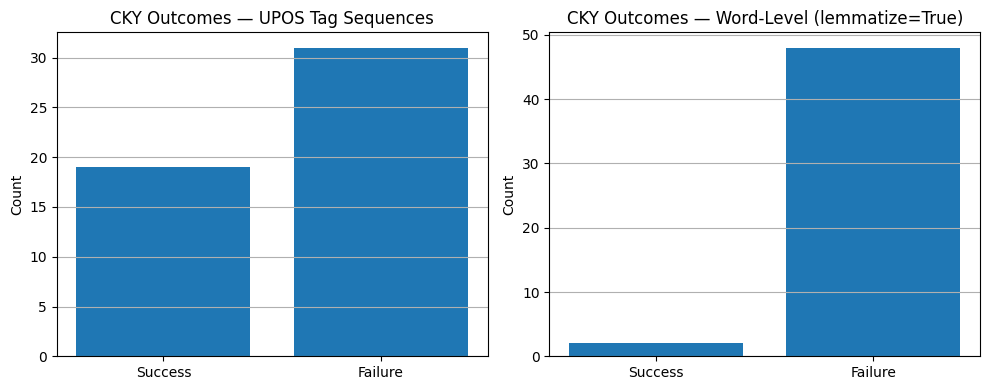

In [89]:
# Plot parse outcomes for both evaluation modes side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, results, title in zip(
    axes,
    [upos_results, word_results],
    ["UPOS Tag Sequences", f"Word-Level (lemmatize={LEMMATIZE})"],
):
    ax.bar(
        ["Success", "Failure"],
        [sum(results), len(results) - sum(results)],
    )
    ax.set_title(f"CKY Outcomes — {title}")
    ax.set_ylabel("Count")
    ax.grid(axis="y")

plt.tight_layout()
plt.show()

### Coverage Analysis

In [90]:
# Compact summary of parsing coverage for both evaluation modes.
coverage_stats = {
    "Eval Sentences":          len(eval_tagged),
    "UPOS Successful Parses":  sum(upos_results),
    "UPOS Success Rate (%)":   round(upos_rate * 100, 2),
    "Word Successful Parses":  sum(word_results),
    "Word Success Rate (%)":   round(word_rate * 100, 2),
    "Lemmatization Active":    LEMMATIZE,
    "Train Size":              len(train_tagged),
}

coverage_stats

{'Eval Sentences': 50,
 'UPOS Successful Parses': 19,
 'UPOS Success Rate (%)': 38.0,
 'Word Successful Parses': 2,
 'Word Success Rate (%)': 4.0,
 'Lemmatization Active': True,
 'Train Size': 400}